In [1]:
# Let's import all the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.DataFrame(
    {
        "Marketing Spend( Million $)": [23, 26, 30, 34, 43, 48],
        "Sales (Million $)": [651, 762, 856, 1063, 1190, 1298],
    }
)

In [3]:
df

,Marketing Spend( Million $),Sales (Million $)
0,23,651
1,26,762
2,30,856
3,34,1063
4,43,1190
5,48,1298


In [47]:
X = df["Marketing Spend( Million $)"].values.reshape(-1, 1)
y = df["Sales (Million $)"]
reg = LinearRegression()
reg.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


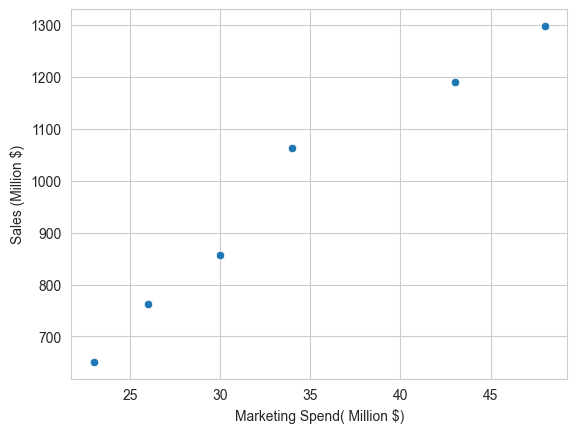

In [4]:
def eda_and_model_creation(df):
    # visualizing the data
    cols = df.columns
    sns.scatterplot(df, x=cols[0], y=cols[1])
    plt.show()
    # creating model
    dfModel = df.copy()
    scaler = MinMaxScaler()

    dfModel[cols] = scaler.fit_transform(df[cols])
    return dfModel


dfModel = eda_and_model_creation(df)

In [5]:
dfModel

,Marketing Spend( Million $),Sales (Million $)
0,0.00,0.000000
1,0.12,0.171561
2,0.28,0.316847
3,0.44,0.636785
4,0.80,0.833076
5,1.00,1.000000


In [6]:
def linear_regression(data):
    lm = LinearRegression()
    cols = data.columns
    X = data[cols[0]].values.reshape(-1, 1)
    y = data[cols[1]]
    lm.fit(X, y)
    # Predictions
    y_pred = lm.predict(X)
    # Scoring
    print("OLS r2 score:", r2_score(y, y_pred))
    return y_pred


y_pred = linear_regression(dfModel)

OLS r2 score: 0.9652190930694494


In [7]:
y_pred

array([0.05907859, 0.17743302, 0.33523892, 0.49304482, 0.8481081 ,
       1.04536548])

In [8]:
# Additional Calculations


def goodness_of_fit(y_true, predictions):
    # RSS
    rss = np.sum(np.square(y_true - predictions))
    # MSE
    mse = mean_squared_error(y_true=y_true, y_pred=predictions)
    rmse = np.sqrt(mse)
    return rss, mse, rmse


values = goodness_of_fit(y_true=dfModel[dfModel.columns[1]], predictions=y_pred)
print(f"RSS: {values[0]}, MSE: {values[1]}, RMSE: {values[2]}")

RSS: 0.02680830738175687, MSE: 0.0044680512302928115, RMSE: 0.06684348308019872


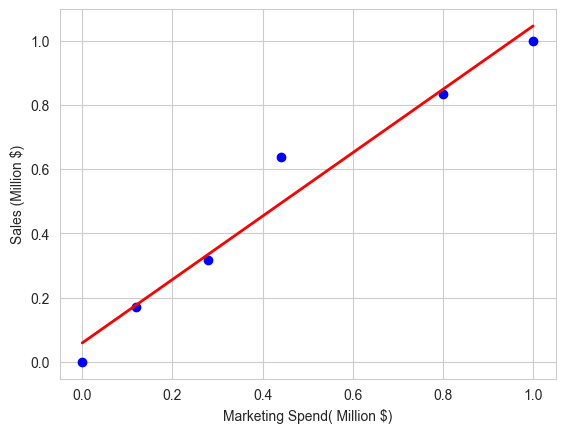

In [9]:
def predicted_visually(data, predictions):
    cols = data.columns
    X, y = data[cols[0]], data[cols[1]]
    plt.scatter(X, y, color="blue")
    plt.plot(X, predictions, color="red", linewidth=2)
    plt.xlabel(cols[0])
    plt.ylabel(cols[1])
    plt.show()


predicted_visually(dfModel, y_pred)

## Let's plot and observe how polynomial regression with higher degrees compares with linear regression

In [10]:
def polynomial_regression(degree):
    poly = PolynomialFeatures(degree)
    X = df["Marketing Spend( Million $)"].values.reshape(-1, 1)
    y = df["Sales (Million $)"]
    outcome = poly.fit_transform(X)

    # for d, row in enumerate(outcome):
    #     print(f"For Drgree:{d}, {row}")

    reg_name = "linreg" + str(degree)

    reg_name = LinearRegression()
    # print(reg)
    reg.fit(outcome, y)

    y_pred_degree = reg.predict(outcome)
    print(f"For degree {degree}, {r2_score(y,y_pred_degree)} ")
    return reg, outcome

In [11]:
def visual_and_predictions(data, degree):
    # Plotting the polynomial regression(degree-5) and simple linear regression
    # Need to make a function for this
    cols = data.columns
    X = data[cols[0]].values.reshape(-1, 1)
    y = data[cols[1]]
    X_seq = np.linspace(X.min(), X.max(), 300).reshape(
        -1, 1
    )  # Between 0 and 1 we get 300 equally spaced values
    # print(X_seq)
    reg = LinearRegression()
    reg.fit(X, y)
    polyreg = PolynomialFeatures(degree)
    linreg, outcome = polynomial_regression(degree)

    linreg.fit(outcome, y)
    y_pred_degree = linreg.predict(outcome)
    print(f"For degree: {degree},r2_score:{r2_score(y,y_pred_degree)}")
    plt.figure()
    plt.scatter(X, y)
    plt.plot(
        X_seq, linreg.predict(polyreg.fit_transform(X_seq)), color="black"
    )  # model fit with polynomial regression
    plt.plot(X_seq, reg.predict(X_seq), color="red")  # model fit with linear regression
    plt.title("Polynomial regression with degree " + str(degree))
    plt.xlabel("Marketing Spend (Million $)")
    plt.ylabel("Predicted Sales (Million $)")
    plt.show()

For degree 2, 0.9853064868700513 
For degree: 2,r2_score:0.9853064868700513


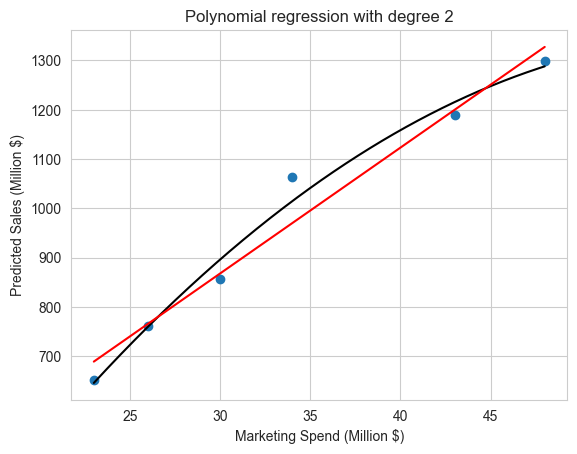

For degree 3, 0.9853552040030629 
For degree: 3,r2_score:0.9853552040030629


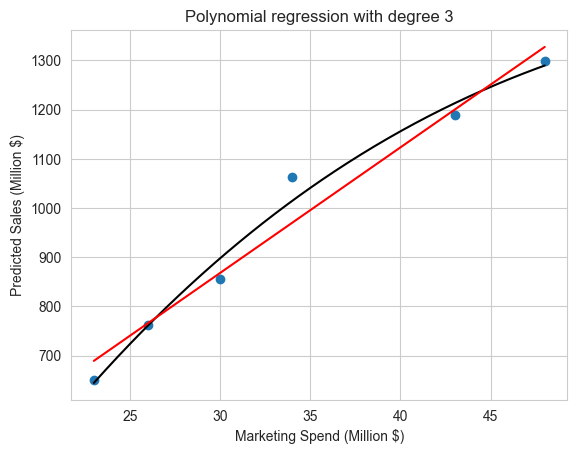

For degree 4, 0.9915572440181046 
For degree: 4,r2_score:0.9915572440181046


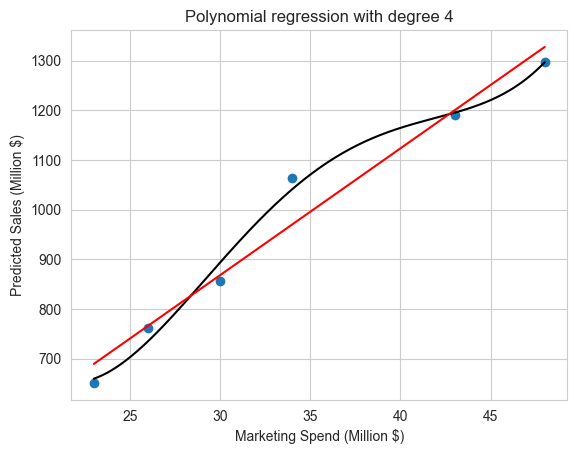

For degree 5, 0.9999999999994991 
For degree: 5,r2_score:0.9999999999994991


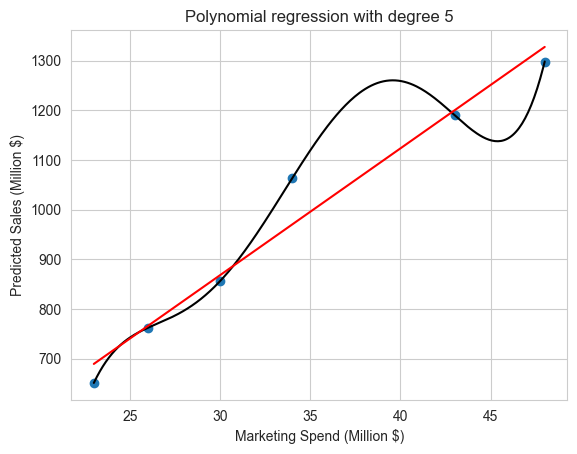

For degree 6, 1.0 
For degree: 6,r2_score:1.0


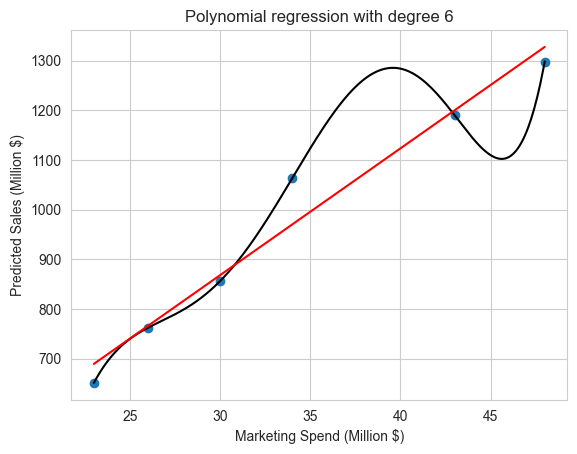

For degree 7, 1.0 
For degree: 7,r2_score:1.0


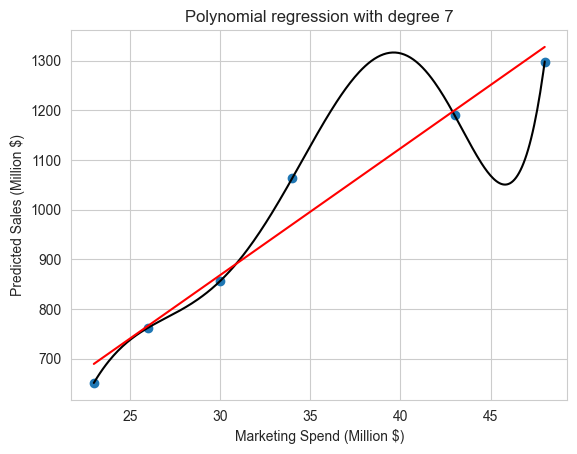

In [12]:
for degree in range(2, 8):
    visual_and_predictions(df, degree)

In [55]:
linredge5, outcome = polynomial_regression(5)

For degree 5, 0.9999999999994991 


In [56]:
outcome

array([[1.00000000e+00, 2.30000000e+01, 5.29000000e+02, 1.21670000e+04,
        2.79841000e+05, 6.43634300e+06],
       [1.00000000e+00, 2.60000000e+01, 6.76000000e+02, 1.75760000e+04,
        4.56976000e+05, 1.18813760e+07],
       [1.00000000e+00, 3.00000000e+01, 9.00000000e+02, 2.70000000e+04,
        8.10000000e+05, 2.43000000e+07],
       [1.00000000e+00, 3.40000000e+01, 1.15600000e+03, 3.93040000e+04,
        1.33633600e+06, 4.54354240e+07],
       [1.00000000e+00, 4.30000000e+01, 1.84900000e+03, 7.95070000e+04,
        3.41880100e+06, 1.47008443e+08],
       [1.00000000e+00, 4.80000000e+01, 2.30400000e+03, 1.10592000e+05,
        5.30841600e+06, 2.54803968e+08]])

In [29]:
X = df["Marketing Spend( Million $)"].values.reshape(-1, 1)
print(X)
y = df["Sales (Million $)"]
reg = LinearRegression()
reg.fit(X, y)

[[23]
 [26]
 [30]
 [34]
 [43]
 [48]]


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
X = dfModel["Marketing Spend( Million $)"].values.reshape(-1, 1)
y = dfModel["Sales (Million $)"]
reg.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Since we can see our model becomes unstable with higher degrees, we can try to reduce them using
## Ridge Regressionm

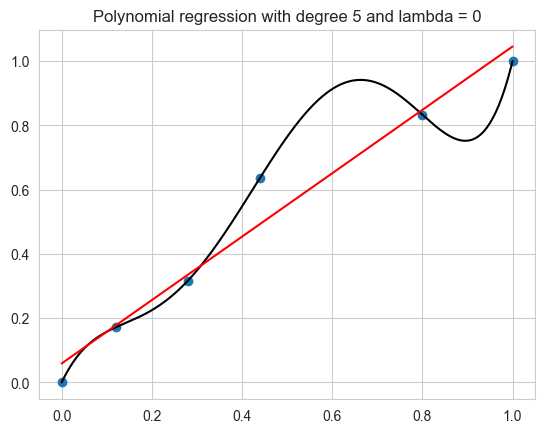

r2 score = 1.0
[  0.           2.94295226 -19.85351777  71.18543313 -95.27426562
  41.99939801]


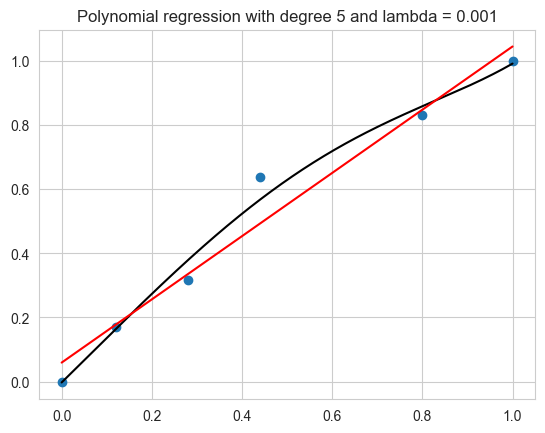

r2 score = 0.9877944050899672
[ 0.          1.3870223   0.12292763 -0.68649391 -0.38094524  0.55241207]


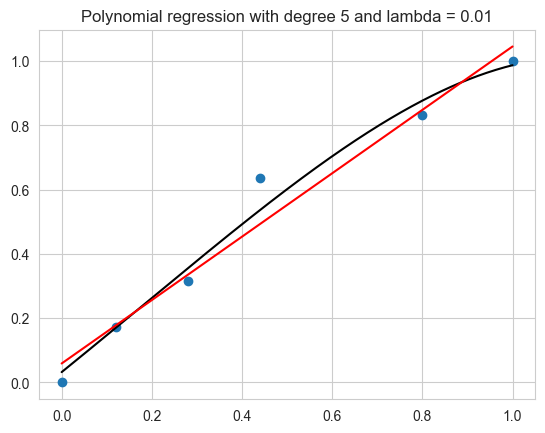

r2 score = 0.9809539612050425
[ 0.          1.13560973  0.13020587 -0.17959473 -0.14842149  0.01704645]


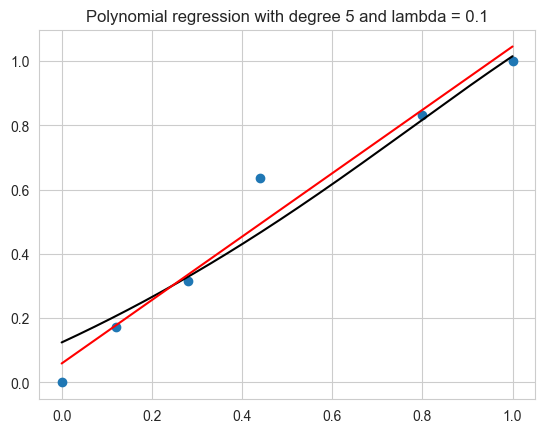

r2 score = 0.9396437428481395
[ 0.          0.65027964  0.2651751   0.07110798 -0.02396289 -0.07201942]


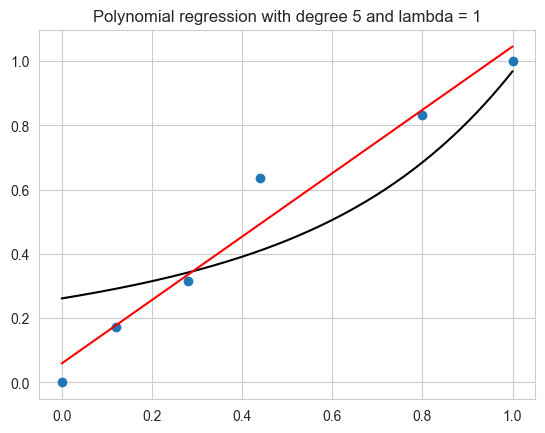

r2 score = 0.7953946450161844
[0.         0.22867197 0.16688081 0.12627838 0.10086186 0.08408679]


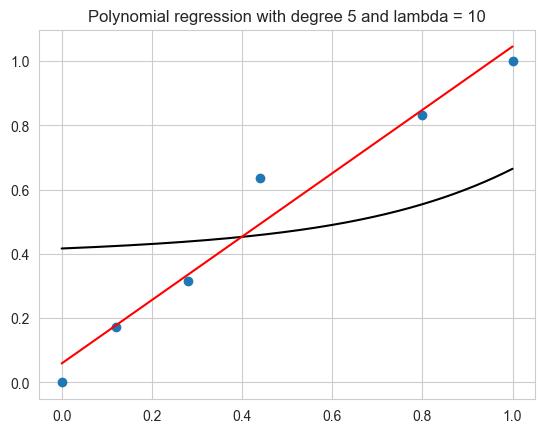

r2 score = 0.3849505189364377
[0.         0.0571764  0.05346191 0.0489761  0.04550657 0.04291024]


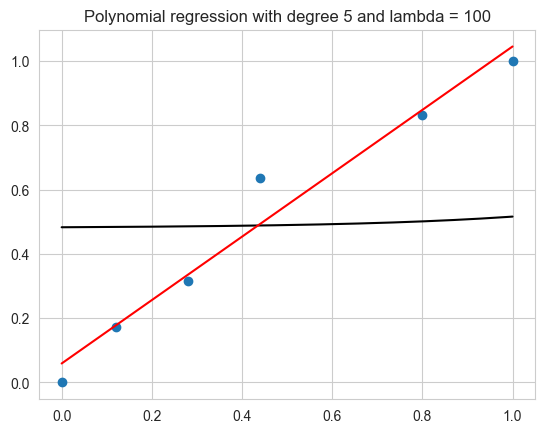

r2 score = 0.058590880289601355
[0.         0.00729918 0.00707285 0.00662207 0.00624288 0.00594789]


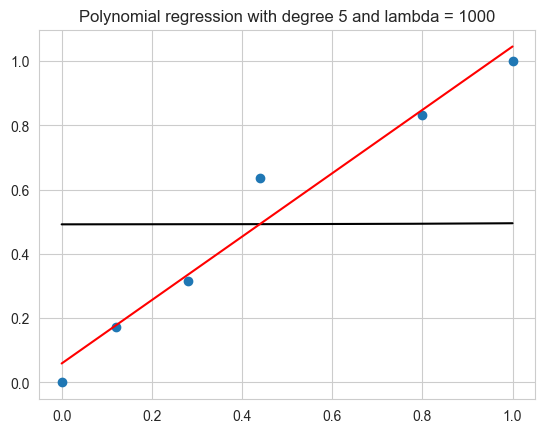

r2 score = 0.006166338591997
[0.         0.00075179 0.0007312  0.00068611 0.00064776 0.00061778]


In [52]:
# Applying Ridge Regression with varying the hyperparameter 'lambda'

X_seq = np.linspace(X.min(), X.max(), 300).reshape(
    -1, 1
)  # values to be considered for predictor variable
lambdas = [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000]  # Higher the value of lambda,
# more the regularization
for i in lambdas:  # for each lambda we get different model coefficients
    degree = 5  # Degree for polynomial regression - chose 5 since this is the lowest number that gave a perfect fit
    # Creating degree 5 features
    ridgecoef = PolynomialFeatures(degree)
    # Transforming input features to polynomial features (1, x1, x2, x3, x4, x5)
    X_poly = ridgecoef.fit_transform(X)
    ridgereg = Ridge(
        alpha=i
    )  # Initialize the Ridge Regression model with a specific lambda
    ridgereg.fit(X_poly, y)  # fit the model on the polynomial features

    # Plotting the ridge regression model for each lambda
    plt.figure()
    plt.scatter(X, y)
    plt.plot(
        X_seq, ridgereg.predict(ridgecoef.fit_transform(X_seq)), color="black"
    )  # Polynomial Regression
    plt.plot(X_seq, reg.predict(X_seq), color="red")  # Linear Regression
    plt.title(
        "Polynomial regression with degree " + str(degree) + " and lambda = " + str(i)
    )
    plt.show()

    # Computing the r2 score
    y_pred = ridgereg.predict(ridgecoef.fit_transform(X))
    print("r2 score = " + str(r2_score(y, y_pred)))
    print(ridgereg.coef_)  # model coefficients

Ridge Regression Formula
$\sum_{i=1}^n (y_{i}-y'_{i})^2$ + $\sum_{j=1}^p\lambda*(\beta_{j})^2$
**We have to tune the hyperparameter $\lambda$ somehow**

## LASSO

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


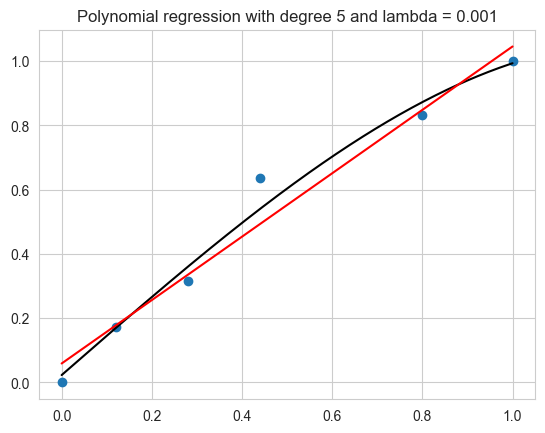

r2 score = 0.9826605659196855
[ 0.          1.22414556 -0.         -0.25396979 -0.         -0.        ]


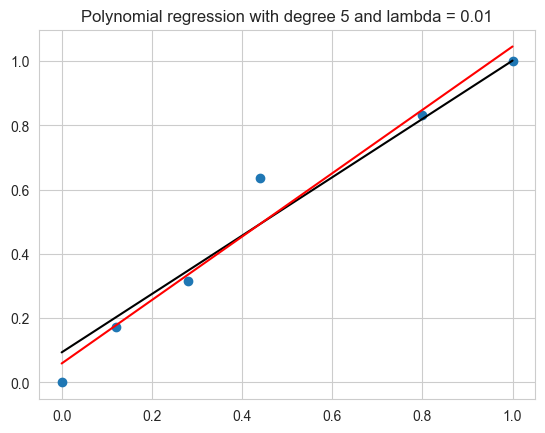

r2 score = 0.9591121182494984
[0.       0.907835 0.       0.       0.       0.      ]


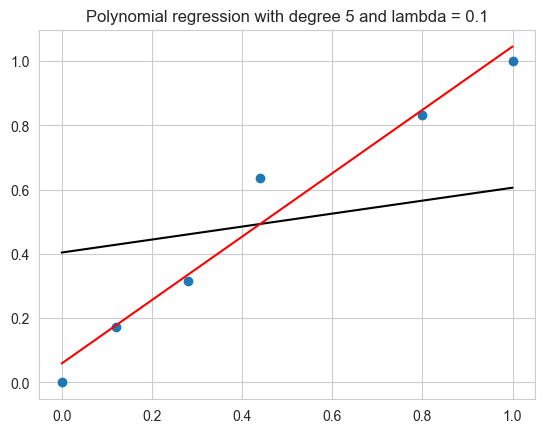

r2 score = 0.3545216110743441
[0.         0.20176806 0.         0.         0.         0.        ]


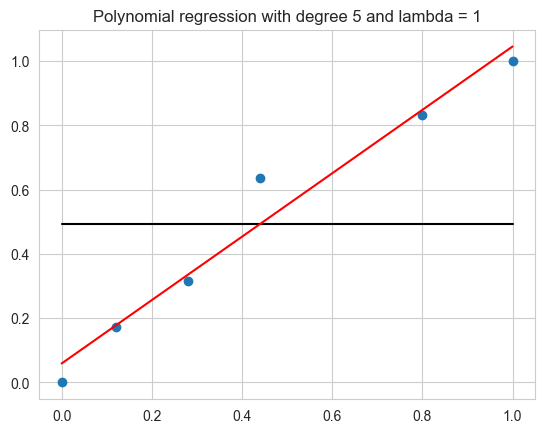

r2 score = 0.0
[0. 0. 0. 0. 0. 0.]


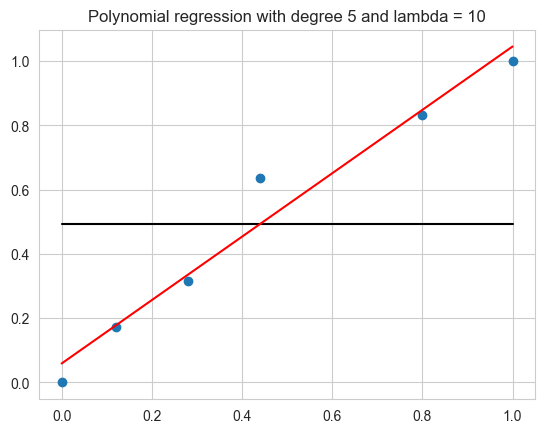

r2 score = 0.0
[0. 0. 0. 0. 0. 0.]


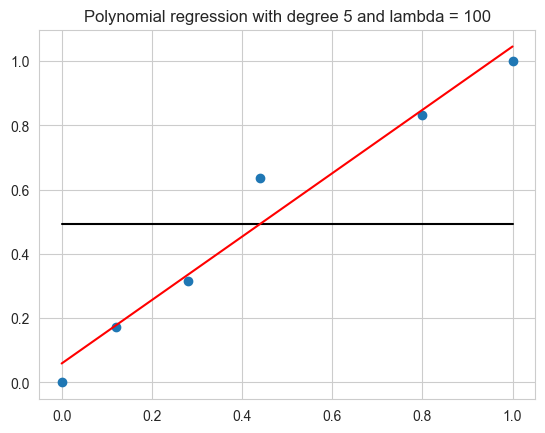

r2 score = 0.0
[0. 0. 0. 0. 0. 0.]


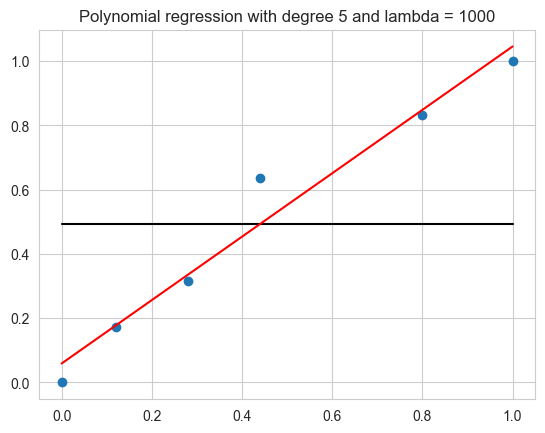

r2 score = 0.0
[0. 0. 0. 0. 0. 0.]


In [53]:
# Applying Lasso Regression with varying the hyperparameter 'lambda'

lambdas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
for i in lambdas:
    degree = 5
    # Creating degree 5 features
    lassocoef = PolynomialFeatures(degree)
    # Transforming input features to polynomial features (1, x1, x2, x3, x4, x5)
    X_poly = lassocoef.fit_transform(X)
    lassoreg = Lasso(alpha=i)
    lassoreg.fit(X_poly, y)
    # Plotting the ridge model
    plt.figure()
    plt.scatter(X, y)
    plt.plot(X_seq, lassoreg.predict(lassocoef.fit_transform(X_seq)), color="black")
    plt.plot(X_seq, reg.predict(X_seq), color="red")
    plt.title(
        "Polynomial regression with degree " + str(degree) + " and lambda = " + str(i)
    )
    plt.show()
    # Compute R^2
    y_pred = lassoreg.predict(lassocoef.fit_transform(X))
    print("r2 score = " + str(r2_score(y, y_pred)))
    print(lassoreg.coef_)

### Ridge and Lasso Regression for specific lambda value

In [54]:
# Get the model coefficients for specific lambda say 0.001

# Ridge Regression
degree = 5
ridgecoef = PolynomialFeatures(degree, include_bias=True)  # Creating degree 5 features
# Transforming input features to polynomial features (1, x1, x2, x3, x4, x5)
X_poly = ridgecoef.fit_transform(X)
ridgereg = Ridge(
    alpha=0.001
)  # Initialize the Ridge Regression model with a specific lambda
ridgereg.fit(X_poly, y)  # fit the model on the polynomial features
print(ridgereg.coef_)
y_pred = ridgereg.predict(ridgecoef.fit_transform(X))
print("r2 score = " + str(r2_score(y, y_pred)))

# Lasso Regression
lassocoef = PolynomialFeatures(degree)  # Creating degree 5 features
# Transforming input features to polynomial features (1, x1, x2, x3, x4, x5)
X_poly = lassocoef.fit_transform(X)
lassoreg = Lasso(alpha=0.001)
lassoreg.fit(X_poly, y)
print(lassoreg.coef_)
y_pred = lassoreg.predict(lassocoef.fit_transform(X))
print("r2 score = " + str(r2_score(y, y_pred)))

[ 0.          1.3870223   0.12292763 -0.68649391 -0.38094524  0.55241207]
r2 score = 0.9877944050899672
[ 0.          1.22414556 -0.         -0.25396979 -0.         -0.        ]
r2 score = 0.9826605659196855


In [58]:
# Building the polynomial regression model with degree 5
degree = 5  # got this number through trial and this is the lowest value which fit the data perfectly
polyreg5 = PolynomialFeatures(degree)
X_poly5 = polyreg5.fit_transform(
    X
)  # Transform the variable X to 1, X, X^2, X^3, X^4, X^5
linreg5 = LinearRegression()
linreg5.fit(X_poly5, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
betas = pd.DataFrame(
    index=["1", "x", "x2", "x3", "x4", "x5"], columns=["Polynomial", "Ridge", "Lasso"]
)
betas["Polynomial"] = linreg5.coef_  # Polynomial Regression
betas["Ridge"] = ridgereg.coef_  # Ridge Regression
betas["Lasso"] = lassoreg.coef_  # Lasso Regression
betas

,Polynomial,Ridge,Lasso
1,0.000000,0.000000,0.000000
x,2.942952,1.387022,1.224146
x2,-19.853518,0.122928,-0.000000
x3,71.185433,-0.686494,-0.253970
x4,-95.274266,-0.380945,-0.000000
x5,41.999398,0.552412,-0.000000
